In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [2]:
import pandas as pd
air_quality_df = pd.read_csv(r"D:\DL Lab 2026\lab02\datasets\air_quality_data.csv")
print("The dataset is: \n",air_quality_df.head())

The dataset is: 
         Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  3/10/2004  18:00:00     2.6         1360       150      11.9   
1  3/10/2004  19:00:00     2.0         1292       112       9.4   
2  3/10/2004  20:00:00     2.2         1402        88       9.0   
3  3/10/2004  21:00:00     2.2         1376        80       9.2   
4  3/10/2004  22:00:00     1.6         1272        51       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0           1046      166          1056      113          1692         1268   
1            955      103          1174       92          1559          972   
2            939      131          1140      114          1555         1074   
3            948      172          1092      122          1584         1203   
4            836      131          1205      116          1490         1110   

      T    RH      AH  
0  13.6  48.9  0.7578  
1  13.3  47.7  0.7255  
2  11.9  54.0  0.7502  
3  11.0 

In [3]:
# Understanding the dataset
print("The information about the air_quality dataset is: \n",air_quality_df.info())
print("\nThe description about the air_quality dataset is: \n",air_quality_df.describe())
print("\nThe shape of the air_quality dataset is: \n",air_quality_df.shape)
print("\nThe columns of the air_quality dataset are: \n",air_quality_df.columns)
print("\nThe datatypes of the columns of the air_quality dataset are: \n",air_quality_df.dtypes)
print("\nThe memory usage of the air_quality dataset is: \n",air_quality_df.memory_usage())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB
The information about the air_quality dataset is: 
 None

The description about the

In [4]:
# find the missing values
print("The missing values in the air_quality dataset are: \n",air_quality_df.isnull().sum())
# input features & target variable
features_air = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
target_air = 'AQI'
print("The input feature in the air_quality dataset are: ", features_air)
print("The target variable in the air_quality dataset is: ", target_air)

The missing values in the air_quality dataset are: 
 Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64
The input feature in the air_quality dataset are:  ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
The target variable in the air_quality dataset is:  AQI


In [5]:
print("The final dataset is looks like: \n", air_quality_df.head())

The final dataset is looks like: 
         Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  3/10/2004  18:00:00     2.6         1360       150      11.9   
1  3/10/2004  19:00:00     2.0         1292       112       9.4   
2  3/10/2004  20:00:00     2.2         1402        88       9.0   
3  3/10/2004  21:00:00     2.2         1376        80       9.2   
4  3/10/2004  22:00:00     1.6         1272        51       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0           1046      166          1056      113          1692         1268   
1            955      103          1174       92          1559          972   
2            939      131          1140      114          1555         1074   
3            948      172          1092      122          1584         1203   
4            836      131          1205      116          1490         1110   

      T    RH      AH  
0  13.6  48.9  0.7578  
1  13.3  47.7  0.7255  
2  11.9  54.0  

In [6]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load dataset
air_quality_df = pd.read_csv(r"D:\DL Lab 2026\lab02\datasets\air_quality_data.csv")

# Define input features and target
features_air = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'T', 'RH', 'AH']
target_air = 'NO2(GT)'

# Normalize input features
scaler_X_air = MinMaxScaler()
air_quality_df[features_air] = scaler_X_air.fit_transform(air_quality_df[features_air])

# Normalize target variable
scaler_y_air = MinMaxScaler()
air_quality_df[[target_air]] = scaler_y_air.fit_transform(air_quality_df[[target_air]])

# Display normalized data
print("Normalized input features:\n", air_quality_df[features_air].head())
print("\nNormalized target variable:\n", air_quality_df[[target_air]].head())

Normalized input features:
      CO(GT)  NMHC(GT)  C6H6(GT)   NOx(GT)         T        RH        AH
0  0.956111  0.251980  0.803565  0.217987  0.873262  0.862141  0.992715
1  0.953280  0.224622  0.794084  0.180465  0.872036  0.857984  0.992556
2  0.954224  0.207343  0.792567  0.197141  0.866312  0.879806  0.992678
3  0.954224  0.201584  0.793326  0.221560  0.862633  0.900589  0.992858
4  0.951392  0.180706  0.783087  0.197141  0.863451  0.899203  0.992869

Normalized target variable:
     NO2(GT)
0  0.579630
1  0.540741
2  0.581481
3  0.596296
4  0.585185


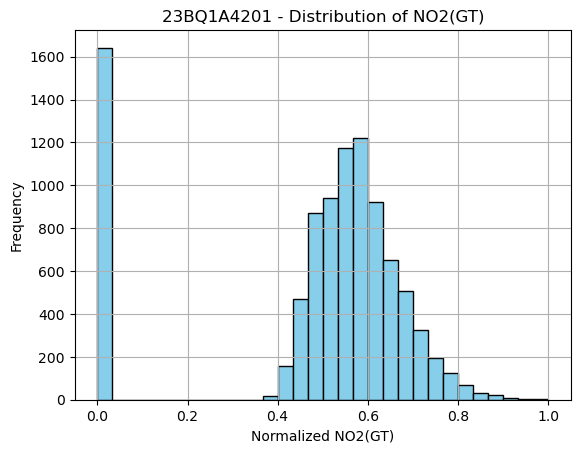

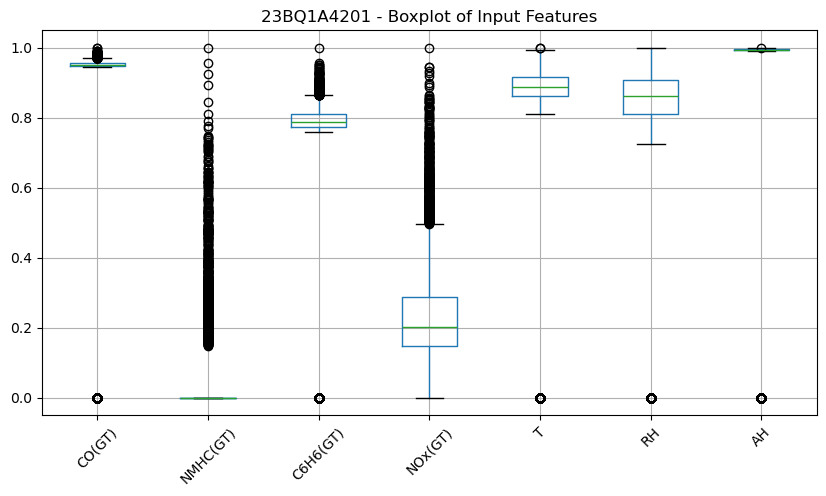

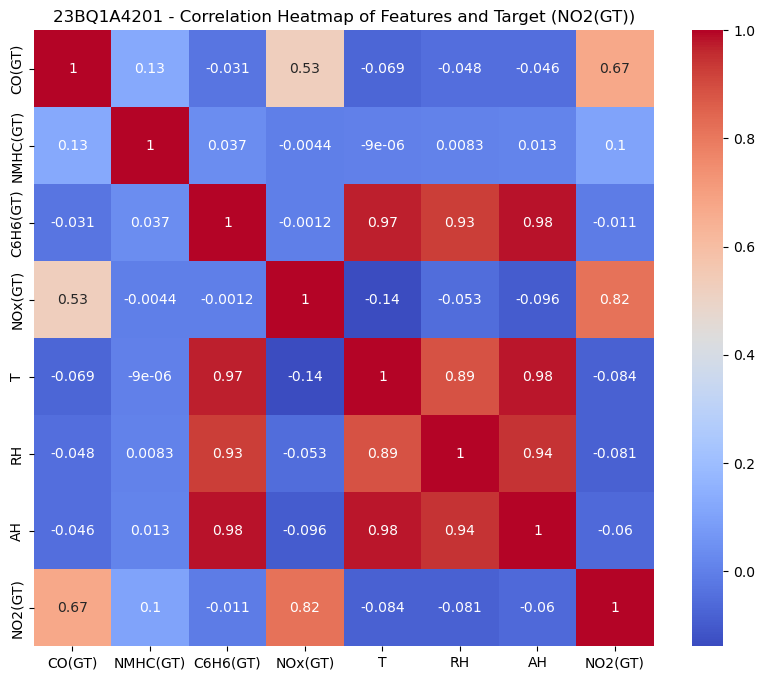

In [7]:
# EDA for Air Quality dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of target
air_quality_df[target_air].hist(bins=30, color='skyblue', edgecolor='black')
plt.title("23BQ1A4201 - Distribution of NO2(GT)")
plt.xlabel("Normalized NO2(GT)")
plt.ylabel("Frequency")
plt.show()

print("\n")

# Boxplot to detect outliers in input features
air_quality_df[features_air].boxplot(figsize=(10,5))
plt.xticks(rotation=45)
plt.title("23BQ1A4201 - Boxplot of Input Features")
plt.show()

print("\n")

# Correlation heatmap (features + target)
plt.figure(figsize=(10,8))
sns.heatmap(air_quality_df[features_air + [target_air]].corr(), annot=True, cmap='coolwarm')
plt.title("23BQ1A4201 - Correlation Heatmap of Features and Target (NO2(GT))")
plt.show()

print("\n")

In [8]:
# Split the Air Quality dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Input features and target
X = air_quality_df[features_air]
y = air_quality_df[target_air]

print("The shape of the input features is: ", X.shape)
print("The shape of the target variable is: ", y.shape)

# Split dataset: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("The shape of the training input features is: ", X_train.shape)
print("The shape of the testing input features is: ", X_test.shape)
print("The shape of the training target variable is: ", y_train.shape)
print("The shape of the testing target variable is: ", y_test.shape)

The shape of the input features is:  (9357, 7)
The shape of the target variable is:  (9357,)
The shape of the training input features is:  (7485, 7)
The shape of the testing input features is:  (1872, 7)
The shape of the training target variable is:  (7485,)
The shape of the testing target variable is:  (1872,)


In [9]:
# Build the ANN (FFNN) Regression Model for Air Quality Dataset
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

# Initialize model
air_quality_model = Sequential()

# Entry Layer
air_quality_model.add(Input(shape=(len(features_air),)))  # 7 input features

# Hidden Layers
air_quality_model.add(Dense(128, activation='relu'))   # Layer 1
air_quality_model.add(Dense(64, activation='relu'))    # Layer 2
air_quality_model.add(Dense(32, activation='relu'))    # Layer 3
air_quality_model.add(Dense(16, activation='relu'))    # Layer 4

# Output Layer
air_quality_model.add(Dense(1, activation='sigmoid'))  # Target normalized 0-1

# Model Summary
print("The model summary is: \n")
air_quality_model.summary()

The model summary is: 



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile the Air Quality ANN Model
from tensorflow.keras.optimizers import Adam

air_quality_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',           # Mean Squared Error for regression
    metrics=['mae']       # Mean Absolute Error
)

# Show model summary after compilation
print("\nThe model summary (After Compilation): \n")
air_quality_model.summary()

print("\nThe model is compiled and ready for training!")


The model summary (After Compilation): 



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 0 (0.00 B)


The model is compiled and ready for training!


In [11]:
# Train the Air Quality ANN Model
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,              # wait for 20 epochs if no improvement
    restore_best_weights=True,
    verbose=1
)

print("Starting Training...")

history_aq = air_quality_model.fit(
    X_train, y_train,
    validation_split=0.2,    # 20% of training data used for validation
    epochs=200,               # maximum epochs
    batch_size=64,            # batch size
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining Complete!")
print(f"Stopped at epoch: {len(history_aq.history['loss'])}")
print(f"Best validation loss: {min(history_aq.history['val_loss']):.4f}")
print(f"Best validation MAE: {min(history_aq.history['val_mae']):.4f}")

Starting Training...
Epoch 1/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0285 - mae: 0.1111 - val_loss: 0.0155 - val_mae: 0.0832
Epoch 2/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0098 - mae: 0.0693 - val_loss: 0.0044 - val_mae: 0.0506
Epoch 3/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0032 - mae: 0.0427 - val_loss: 0.0022 - val_mae: 0.0353
Epoch 4/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0026 - mae: 0.0380 - val_loss: 0.0020 - val_mae: 0.0337
Epoch 5/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0022 - mae: 0.0332 - val_loss: 0.0018 - val_mae: 0.0305
Epoch 6/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0021 - mae: 0.0324 - val_loss: 0.0023 - val_mae: 0.0360
Epoch 7/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0020 - mae: 0.0316 - val_loss: 0.0018 - val_mae: 0.0303
Epoch 8/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0020 - mae: 0.0317 - val_loss: 0.0019 - val_mae: 0.0318
Epoch 9/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [12]:
# Evaluate the Air Quality ANN Model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict on test set
y_pred = air_quality_model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print("\n===== MODEL PERFORMANCE =====")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

===== MODEL PERFORMANCE =====
MSE: 0.0012
RMSE: 0.0352
MAE: 0.0221
R2 Score: 0.9766


In [13]:
import pandas as pd

# Comparison Table: Actual vs Predicted NO2(GT)
comparison_df = pd.DataFrame({
    "Actual_NO2": y_test.values.flatten(),
    "Predicted_NO2": y_pred.flatten()
})

print("\nSample Predictions:")
print(comparison_df.head(10))


Sample Predictions:
   Actual_NO2  Predicted_NO2
0    0.503704       0.541007
1    0.459259       0.461511
2    0.640741       0.634454
3    0.681481       0.686829
4    0.740741       0.660319
5    0.000000       0.000416
6    0.629630       0.596011
7    0.538889       0.556341
8    0.468519       0.488501
9    0.494444       0.511354


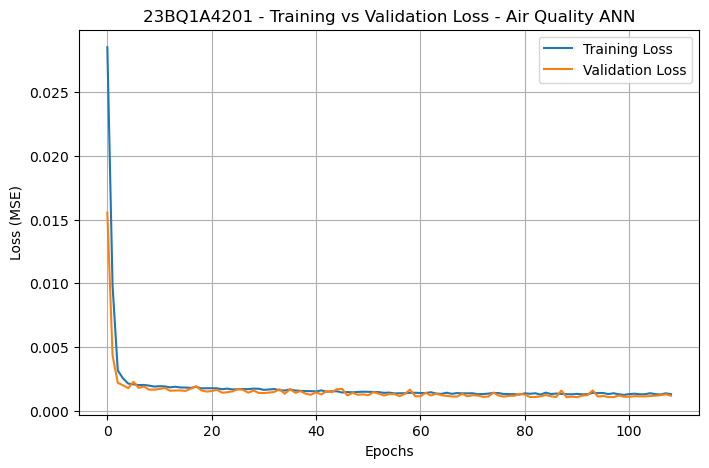

In [14]:
import matplotlib.pyplot as plt

# Plot Training & Validation Loss
plt.figure(figsize=(8,5))
plt.plot(history_aq.history['loss'], label='Training Loss')
plt.plot(history_aq.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("23BQ1A4201 - Training vs Validation Loss - Air Quality ANN")
plt.legend()
plt.grid(True)
plt.show()

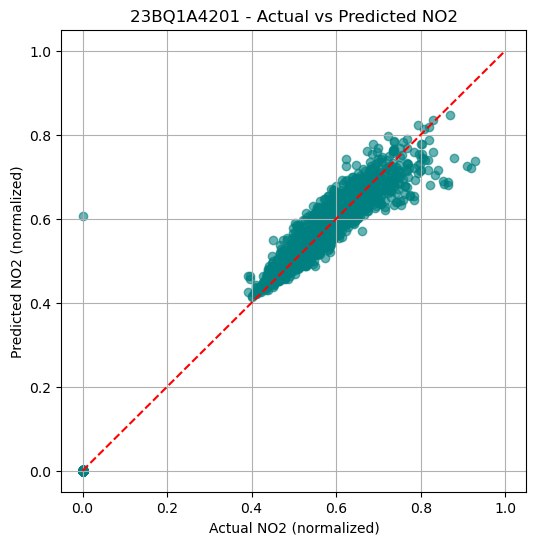

In [15]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([0,1], [0,1], color='red', linestyle='--')  # perfect prediction line
plt.xlabel("Actual NO2 (normalized)")
plt.ylabel("Predicted NO2 (normalized)")
plt.title("23BQ1A4201 - Actual vs Predicted NO2")
plt.grid(True)
plt.show()

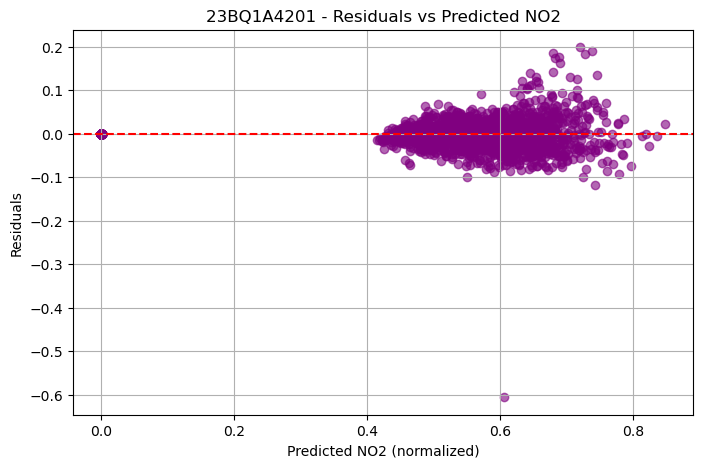

In [16]:
# plot residual plot
residuals = y_test - y_pred.flatten()
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted NO2 (normalized)")
plt.ylabel("Residuals")
plt.title("23BQ1A4201 - Residuals vs Predicted NO2")
plt.grid(True)
plt.show()